# Online Shoppers Purchasing Intention — Preprocessing + Decision Tree (Optuna Tuning)

Notebook tunggal (satu file, end-to-end) untuk memprediksi purchase intention (`Revenue`) pada **Online Shoppers Purchasing Intention Dataset** dari UCI Machine Learning Repository.

- **Sumber dataset:** https://archive.ics.uci.edu/dataset/468/online%20shoppers%20purchasing%20intention%20dataset
- **Kaggle Dataset (mirror publik):** https://www.kaggle.com/datasets/dimaspashaakrilian/online-shoppers-purchasing-intention-dataset

**Alur notebook:**
1. Eksplorasi Data (EDA) & Cleaning
2. Feature Engineering & Encoding
3. Train-Test Split
4. Baseline Decision Tree
5. Hyperparameter Tuning dengan **Optuna** (objective: PR-AUC 5-fold CV)
6. **Precision-Recall Curve & Threshold Optimization** (out-of-fold, tanpa leakage ke test set)
7. Evaluasi Final & Simpan Model

**Model final: Decision Tree.** Dipilih karena murah secara komputasi (tidak perlu scaling, training cepat, tidak menyimpan seluruh dataset seperti KNN, tidak sebanyak pohon seperti Random Forest) dengan performa yang jauh lebih baik dan stabil untuk target yang imbalanced (~85% False / ~15% True) dibanding model-model murah lain (KNN, Naive Bayes) yang sempat dieksplorasi.

Dijalankan sepenuhnya di **CPU** (accelerator: None, bukan GPU T4).

In [1]:
import os
import glob
import time
import json as _json

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix,
)

try:
    import optuna
except ImportError:
    import sys as _sys
    get_ipython().system(f'{_sys.executable} -m pip install -q optuna')
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("optuna version:", optuna.__version__)


optuna version: 4.9.0


/tmp/claude-1000/-home-pasha-akrilian-Documents-Kuliah/2a19719e-8ed7-486e-a1dc-a02c61afee26/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Memuat Data

Mencoba beberapa lokasi umum: input Kaggle Dataset, lalu fallback ke file lokal.

In [2]:
FILENAME = "online_shoppers_intention.csv"

candidate_paths = [
    f"/kaggle/input/online-shoppers-purchasing-intention-dataset/{FILENAME}",
    f"../input/online-shoppers-purchasing-intention-dataset/{FILENAME}",
    FILENAME,
    f"../online+shoppers+purchasing+intention+dataset/{FILENAME}",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_path is None:
    matches = glob.glob(f"/kaggle/input/**/{FILENAME}", recursive=True)
    if matches:
        data_path = matches[0]

if data_path is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pastikan Kaggle Dataset "
        "'dimaspashaakrilian/online-shoppers-purchasing-intention-dataset' sudah ditambahkan "
        "sebagai data source pada notebook ini (Add Data)."
    )

print("Membaca dataset dari:", data_path)
df = pd.read_csv(data_path)
df.shape


Membaca dataset dari: online_shoppers_intention.csv


(12330, 18)

## 1. Eksplorasi Data Awal (EDA)

In [3]:
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print("Tidak ada missing value pada dataset ini.")


Tidak ada missing value pada dataset ini.


In [6]:
n_dupes = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dupes} dari {len(df)} baris ({n_dupes/len(df):.2%})")


Jumlah baris duplikat: 125 dari 12330 baris (1.01%)


In [7]:
target_dist = df["Revenue"].value_counts(normalize=True).rename("proportion").to_frame()
target_dist["count"] = df["Revenue"].value_counts()
target_dist


,proportion,count
Revenue,,
False,0.845255,10422
True,0.154745,1908


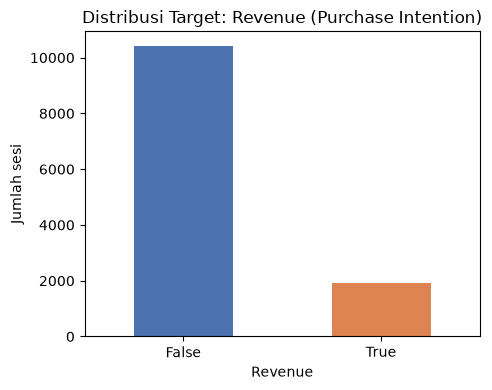

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Revenue"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Distribusi Target: Revenue (Purchase Intention)")
ax.set_xlabel("Revenue")
ax.set_ylabel("Jumlah sesi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Catatan EDA:**
- 12.330 baris sesi kunjungan e-commerce, 17 fitur + 1 target (`Revenue`), tidak ada missing value.
- Terdapat baris duplikat yang akan dibuang.
- Target imbalanced (~85% False / ~15% True) → accuracy saja tidak cukup, evaluasi fokus ke PR-AUC/F1/threshold optimization.
- Fitur kategorikal nominal: `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`.

## 2. Data Cleaning

In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Baris sebelum: {before}, sesudah drop_duplicates: {after}, dibuang: {before - after}")


Baris sebelum: 12330, sesudah drop_duplicates: 12205, dibuang: 125


## 3. Feature Engineering & Encoding

1. `Weekend`/`Revenue` → 0/1.
2. One-hot encoding untuk fitur kategorikal nominal.
3. Fitur numerik dibiarkan apa adanya — scaling dilakukan di dalam `Pipeline` (fit hanya pada data train), menghindari data leakage.

In [10]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

categorical_nominal = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
df_encoded = pd.get_dummies(df, columns=categorical_nominal, drop_first=True)

bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape sebelum encoding:", df.shape)
print("Shape sesudah encoding:", df_encoded.shape)
df_encoded.head()


Shape sebelum encoding: (12205, 18)
Shape sesudah encoding: (12205, 69)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Train-Test Split

Split stratified 80/20 berdasarkan target `Revenue`.

In [11]:
X = df_encoded.drop(columns=["Revenue"])
y = df_encoded["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nProporsi target - train:")
print(y_train.value_counts(normalize=True))
print("\nProporsi target - test:")
print(y_test.value_counts(normalize=True))


X_train: (9764, 68) | X_test: (2441, 68)

Proporsi target - train:
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64

Proporsi target - test:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64


## 5. Baseline Decision Tree (default, untuk pembanding)

In [12]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

t0 = time.perf_counter()
baseline_pipe.fit(X_train, y_train)
baseline_fit_time = time.perf_counter() - t0

y_proba_baseline = baseline_pipe.predict_proba(X_test)[:, 1]
y_pred_baseline = baseline_pipe.predict(X_test)

print(f"Baseline fit_time       : {baseline_fit_time:.4f} s")
print(f"Baseline F1 (thr=0.5)   : {f1_score(y_test, y_pred_baseline):.4f}")
print(f"Baseline PR-AUC (AP)    : {average_precision_score(y_test, y_proba_baseline):.4f}")
print(f"Baseline ROC-AUC        : {roc_auc_score(y_test, y_proba_baseline):.4f}")


Baseline fit_time       : 0.0888 s
Baseline F1 (thr=0.5)   : 0.5689
Baseline PR-AUC (AP)    : 0.3890
Baseline ROC-AUC        : 0.7484


## 6. Hyperparameter Tuning dengan Optuna

Objective: memaksimalkan **rata-rata PR-AUC (average precision) 5-fold cross-validation** di data train — PR-AUC dipilih karena lebih sensitif terhadap performa kelas minoritas dibanding ROC-AUC/accuracy pada data imbalanced.

**Kenapa Optuna, bukan `GridSearchCV`?** Search space mencakup `ccp_alpha` (cost-complexity pruning) yang kontinu. Optuna (TPE sampler, Bayesian-ish) mengeksplorasi ruang kontinu ini jauh lebih efisien daripada menebak titik-titik grid secara manual, sambil tetap sangat cepat karena Decision Tree murah secara komputasi.

In [13]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 40),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.01),
    }
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, **params)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    return scores.mean()


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)

t0 = time.perf_counter()
study.optimize(objective, n_trials=50, show_progress_bar=False)
tuning_time = time.perf_counter() - t0

print(f"Waktu tuning Optuna     : {tuning_time:.1f} detik ({len(study.trials)} trials)")
print(f"Best CV PR-AUC (AP)     : {study.best_value:.4f}")
print(f"Best params             : {study.best_params}")


Waktu tuning Optuna     : 15.9 detik (50 trials)
Best CV PR-AUC (AP)     : 0.7135
Best params             : {'max_depth': 13, 'min_samples_split': 22, 'min_samples_leaf': 33, 'criterion': 'entropy', 'class_weight': None, 'ccp_alpha': 0.0005522283003781191}


/tmp/ipykernel_13492/3842927497.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


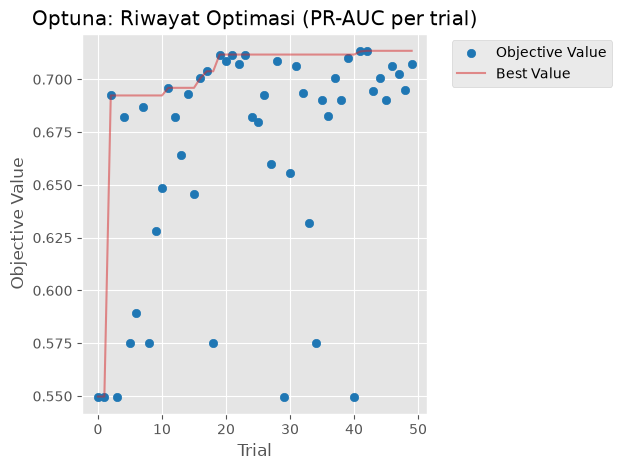

In [14]:
try:
    from optuna.visualization.matplotlib import plot_optimization_history
    ax = plot_optimization_history(study)
    ax.set_title("Optuna: Riwayat Optimasi (PR-AUC per trial)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Skip plot riwayat optimasi:", e)


### 6.1 Model Final: Decision Tree dengan Best Params

In [15]:
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, **study.best_params)),
])

t0 = time.perf_counter()
final_pipe.fit(X_train, y_train)
final_fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba_test = final_pipe.predict_proba(X_test)[:, 1]
y_pred_test_default = final_pipe.predict(X_test)
final_predict_time = time.perf_counter() - t0

print(f"Fit time (full train)   : {final_fit_time:.4f} s")
print(f"Predict time (test)     : {final_predict_time:.4f} s")
print(f"Test F1 (thr=0.5)       : {f1_score(y_test, y_pred_test_default):.4f}")
print(f"Test PR-AUC (AP)        : {average_precision_score(y_test, y_proba_test):.4f}")
print(f"Test ROC-AUC            : {roc_auc_score(y_test, y_proba_test):.4f}")


Fit time (full train)   : 0.0692 s
Predict time (test)     : 0.0068 s
Test F1 (thr=0.5)       : 0.6572
Test PR-AUC (AP)        : 0.6864
Test ROC-AUC            : 0.9181


## 7. Threshold Tuning via PR Curve (Out-of-Fold, tanpa leakage)

Threshold optimal dicari dari **prediksi out-of-fold cross-validation di data TRAIN** (`cross_val_predict`), bukan langsung dari test set — supaya pemilihan threshold tidak *leak* informasi test set ke proses pemilihan model. Threshold yang ditemukan lalu diterapkan apa adanya ke test set untuk evaluasi akhir yang jujur.

In [16]:
oof_proba = cross_val_predict(
    final_pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Threshold optimal (OOF train, maksimalkan F1) : {optimal_threshold:.4f}")
print(f"  -> precision (OOF) @ threshold ini           : {precisions[best_idx]:.4f}")
print(f"  -> recall (OOF) @ threshold ini               : {recalls[best_idx]:.4f}")
print(f"  -> F1 (OOF) @ threshold ini                   : {f1_scores[best_idx]:.4f}")


Threshold optimal (OOF train, maksimalkan F1) : 0.3558
  -> precision (OOF) @ threshold ini           : 0.6538
  -> recall (OOF) @ threshold ini               : 0.6979
  -> F1 (OOF) @ threshold ini                   : 0.6751


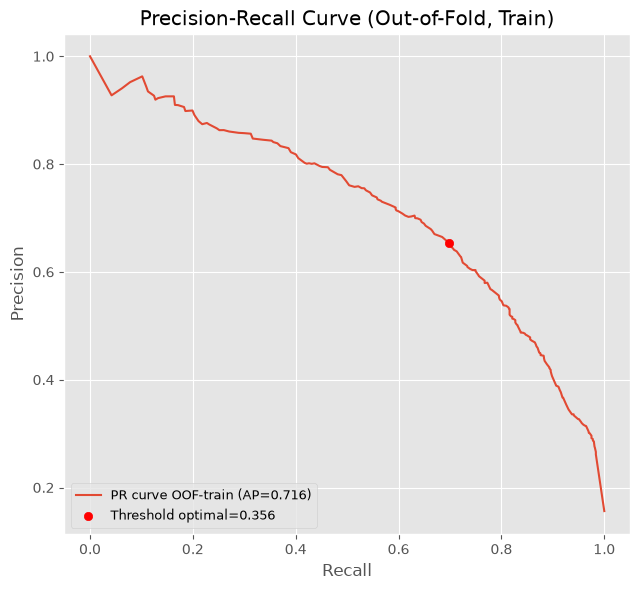

In [17]:
plt.figure(figsize=(6.5, 6))
plt.plot(recalls, precisions, label=f"PR curve OOF-train (AP={average_precision_score(y_train, oof_proba):.3f})")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5,
            label=f"Threshold optimal={optimal_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Out-of-Fold, Train)")
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()


## 8. Evaluasi Final di Test Set: Threshold Default (0.5) vs Threshold Optimal

In [18]:
y_pred_test_optimal = (y_proba_test >= optimal_threshold).astype(int)

final_comparison = pd.DataFrame([
    {
        "threshold": 0.5,
        "accuracy": accuracy_score(y_test, y_pred_test_default),
        "precision": precision_score(y_test, y_pred_test_default),
        "recall": recall_score(y_test, y_pred_test_default),
        "f1": f1_score(y_test, y_pred_test_default),
    },
    {
        "threshold": optimal_threshold,
        "accuracy": accuracy_score(y_test, y_pred_test_optimal),
        "precision": precision_score(y_test, y_pred_test_optimal),
        "recall": recall_score(y_test, y_pred_test_optimal),
        "f1": f1_score(y_test, y_pred_test_optimal),
    },
], index=["default (0.5)", "optimal (PR curve, OOF)"])

final_comparison


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.901270,0.719626,0.604712,0.657183
"optimal (PR curve, OOF)",0.355828,0.893896,0.654912,0.680628,0.667522


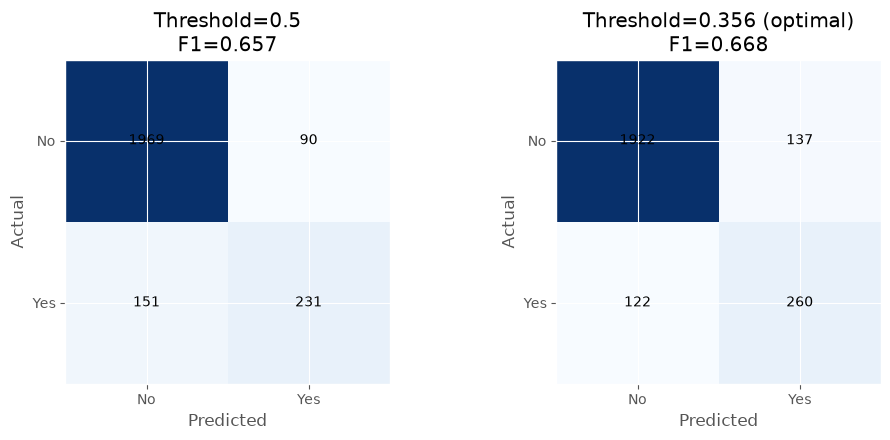

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

cm_default = confusion_matrix(y_test, y_pred_test_default)
axes[0].imshow(cm_default, cmap="Blues")
axes[0].set_title(f"Threshold=0.5\nF1={final_comparison.loc['default (0.5)', 'f1']:.3f}")

cm_optimal = confusion_matrix(y_test, y_pred_test_optimal)
axes[1].imshow(cm_optimal, cmap="Blues")
axes[1].set_title(f"Threshold={optimal_threshold:.3f} (optimal)\nF1={final_comparison.loc['optimal (PR curve, OOF)', 'f1']:.3f}")

for ax, cm in zip(axes, [cm_default, cm_optimal]):
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No", "Yes"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


### 8.1 PR Curve & ROC Curve di Test Set (posisi kedua threshold ditandai)

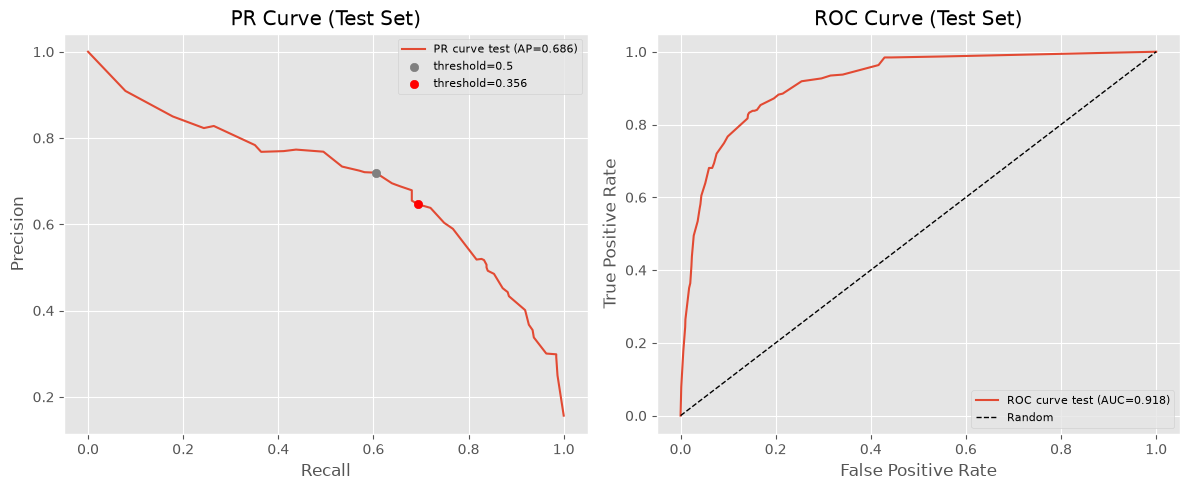

In [20]:
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_test, y_proba_test)
fpr_t, tpr_t, roc_thresholds_t = roc_curve(y_test, y_proba_test)

def closest_idx(arr, value):
    return int(np.argmin(np.abs(arr - value)))

idx_default = closest_idx(thresholds_t, 0.5)
idx_optimal = closest_idx(thresholds_t, optimal_threshold)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(recalls_t, precisions_t, label=f"PR curve test (AP={average_precision_score(y_test, y_proba_test):.3f})")
axes[0].scatter(recalls_t[idx_default], precisions_t[idx_default], color="gray", label="threshold=0.5", zorder=5)
axes[0].scatter(recalls_t[idx_optimal], precisions_t[idx_optimal], color="red", label=f"threshold={optimal_threshold:.3f}", zorder=5)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR Curve (Test Set)")
axes[0].legend(fontsize=8)

axes[1].plot(fpr_t, tpr_t, label=f"ROC curve test (AUC={roc_auc_score(y_test, y_proba_test):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9. Simpan Model Final & Hasil

In [21]:
import joblib

out_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

model_path = os.path.join(out_dir, "final_decision_tree_model.joblib")
joblib.dump(final_pipe, model_path)

final_result = {
    "model": "Decision Tree (Optuna-tuned, FINAL)",
    "best_params": study.best_params,
    "best_cv_pr_auc": study.best_value,
    "optimal_threshold": float(optimal_threshold),
    "fit_time_sec": final_fit_time,
    "predict_time_test_sec": final_predict_time,
    "test_metrics_threshold_0.5": final_comparison.loc["default (0.5)"].to_dict(),
    "test_metrics_threshold_optimal": final_comparison.loc["optimal (PR curve, OOF)"].to_dict(),
    "test_roc_auc": roc_auc_score(y_test, y_proba_test),
    "test_pr_auc": average_precision_score(y_test, y_proba_test),
}

metrics_path = os.path.join(out_dir, "final_decision_tree_metrics.json")
with open(metrics_path, "w") as f:
    _json.dump(final_result, f, indent=2, default=str)

final_comparison.to_csv(os.path.join(out_dir, "decision_tree_threshold_comparison.csv"))

print("Model final disimpan ke  :", model_path)
print("Metrics final disimpan ke:", metrics_path)


Model final disimpan ke  : ./final_decision_tree_model.joblib
Metrics final disimpan ke: ./final_decision_tree_metrics.json


## Kesimpulan

**Model final: Decision Tree**, di-tuning dengan **Optuna** (TPE sampler, 50 trials, objective = PR-AUC 5-fold CV), dengan **threshold keputusan yang juga dioptimalkan lewat PR curve** (out-of-fold, bukan dari test set — menghindari data leakage).

Decision Tree dipilih sebagai model final karena murah secara komputasi (training cepat, tidak perlu scaling secara konseptual, tidak menyimpan seluruh dataset seperti KNN, tidak sebanyak pohon seperti Random Forest/boosting) sekaligus memberi performa yang jauh lebih baik dan stabil dibanding model murah lain untuk target yang imbalanced.

Lihat tabel `final_comparison` di Bagian 8 untuk perbandingan lengkap performa pada threshold default (0.5) vs threshold optimal hasil PR curve.

File output: `final_decision_tree_model.joblib`, `final_decision_tree_metrics.json`, `decision_tree_threshold_comparison.csv`.